<a href="https://www.kaggle.com/code/lalit7881/r-d-survey-2025-eda-100?scriptVersionId=318847769" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lalit7881/research-and-development-survey-2025/research-and-development-survey-2025.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/research-and-development-survey-2025/research-and-development-survey-2025.csv")

In [3]:
df.head()

,Variable,Breakdown,Breakdown_category,Year,RD_Value,Status,Unit,Footnotes,Relative_Sampling_Error
0,_01_Total_RD_Expenditure,ANZSIC_1_Digit,"A_Agriculture, Forestry and Fishing",2016,91,NaN,NZ Dollars (millions),12,23.8
1,_01_Total_RD_Expenditure,ANZSIC_1_Digit,"A_Agriculture, Forestry and Fishing",2018,89,NaN,NZ Dollars (millions),12,51.7
2,_01_Total_RD_Expenditure,ANZSIC_1_Digit,"A_Agriculture, Forestry and Fishing",2019,...,NaN,NZ Dollars (millions),12,...
3,_01_Total_RD_Expenditure,ANZSIC_1_Digit,"A_Agriculture, Forestry and Fishing",2020,99,NaN,NZ Dollars (millions),12,30.2
4,_01_Total_RD_Expenditure,ANZSIC_1_Digit,"A_Agriculture, Forestry and Fishing",2021,...,NaN,NZ Dollars (millions),12,...


In [4]:
df.tail()

,Variable,Breakdown,Breakdown_category,Year,RD_Value,Status,Unit,Footnotes,Relative_Sampling_Error
54944,_95_Total_RD_Expenditure_as_a_proportion_of_GDP,Country,United States,2020,3.41,R,Percentage of GDP,33 and 34,..
54945,_95_Total_RD_Expenditure_as_a_proportion_of_GDP,Country,United States,2021,3.46,R,Percentage of GDP,33 and 34,..
54946,_95_Total_RD_Expenditure_as_a_proportion_of_GDP,Country,United States,2022,3.48,R,Percentage of GDP,33 and 34,..
54947,_95_Total_RD_Expenditure_as_a_proportion_of_GDP,Country,United States,2023,3.42,R,Percentage of GDP,33 and 34,..
54948,_95_Total_RD_Expenditure_as_a_proportion_of_GDP,Country,United States,2024,3.44,R,Percentage of GDP,33 and 34,..


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54949 entries, 0 to 54948
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Variable                 54949 non-null  object
 1   Breakdown                54949 non-null  object
 2   Breakdown_category       54949 non-null  object
 3   Year                     54949 non-null  int64 
 4   RD_Value                 54949 non-null  object
 5   Status                   1989 non-null   object
 6   Unit                     54949 non-null  object
 7   Footnotes                54949 non-null  object
 8   Relative_Sampling_Error  54949 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.8+ MB


In [6]:
df.describe()

,Year
count,54949.000000
mean,2020.859561
std,2.766051
min,2016.000000
25%,2019.000000
50%,2021.000000
75%,2023.000000
max,2025.000000


In [7]:
df.isnull()

,Variable,Breakdown,Breakdown_category,Year,RD_Value,Status,Unit,Footnotes,Relative_Sampling_Error
0,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
54944,False,False,False,False,False,False,False,False,False
54945,False,False,False,False,False,False,False,False,False
54946,False,False,False,False,False,False,False,False,False
54947,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Variable                       0
Breakdown                      0
Breakdown_category             0
Year                           0
RD_Value                       0
Status                     52960
Unit                           0
Footnotes                      0
Relative_Sampling_Error        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Variable', 'Breakdown', 'Breakdown_category', 'Year', 'RD_Value',
       'Status', 'Unit', 'Footnotes', 'Relative_Sampling_Error'],
      dtype='object')

In [11]:
df.nunique()

Variable                    130
Breakdown                     7
Breakdown_category           96
Year                         10
RD_Value                   1468
Status                        1
Unit                          5
Footnotes                   190
Relative_Sampling_Error    1884
dtype: int64

In [12]:
df.dtypes

Variable                   object
Breakdown                  object
Breakdown_category         object
Year                        int64
RD_Value                   object
Status                     object
Unit                       object
Footnotes                  object
Relative_Sampling_Error    object
dtype: object

In [13]:
df.shape

(54949, 9)

## EDA

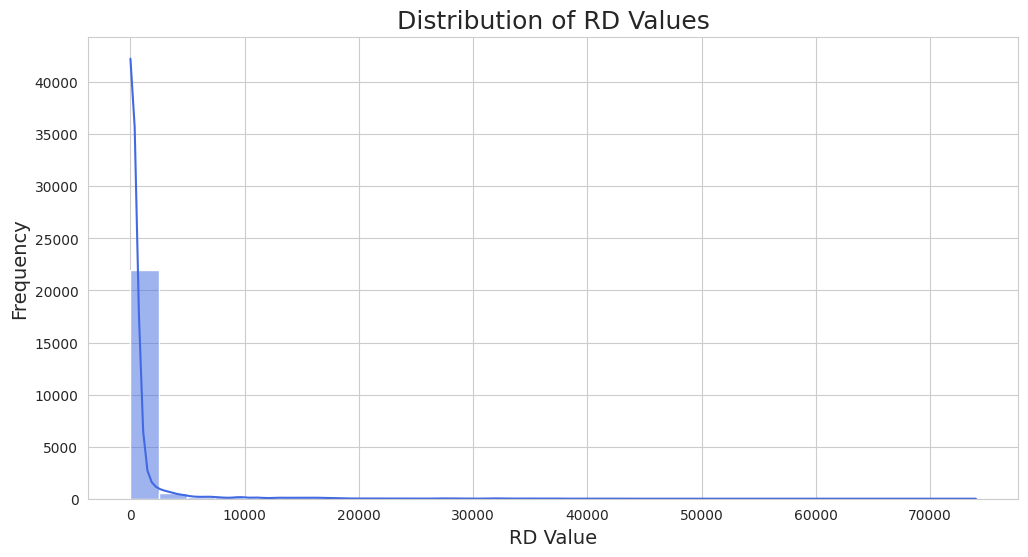

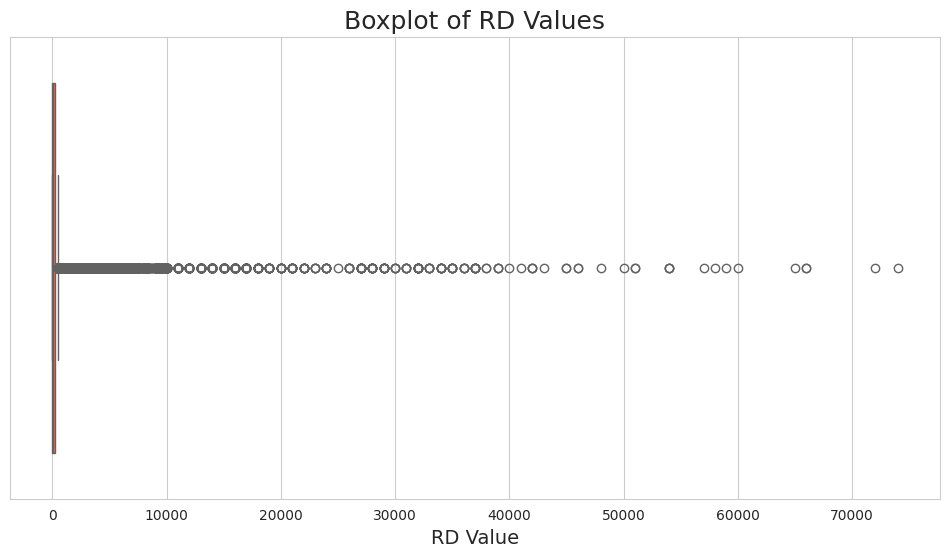

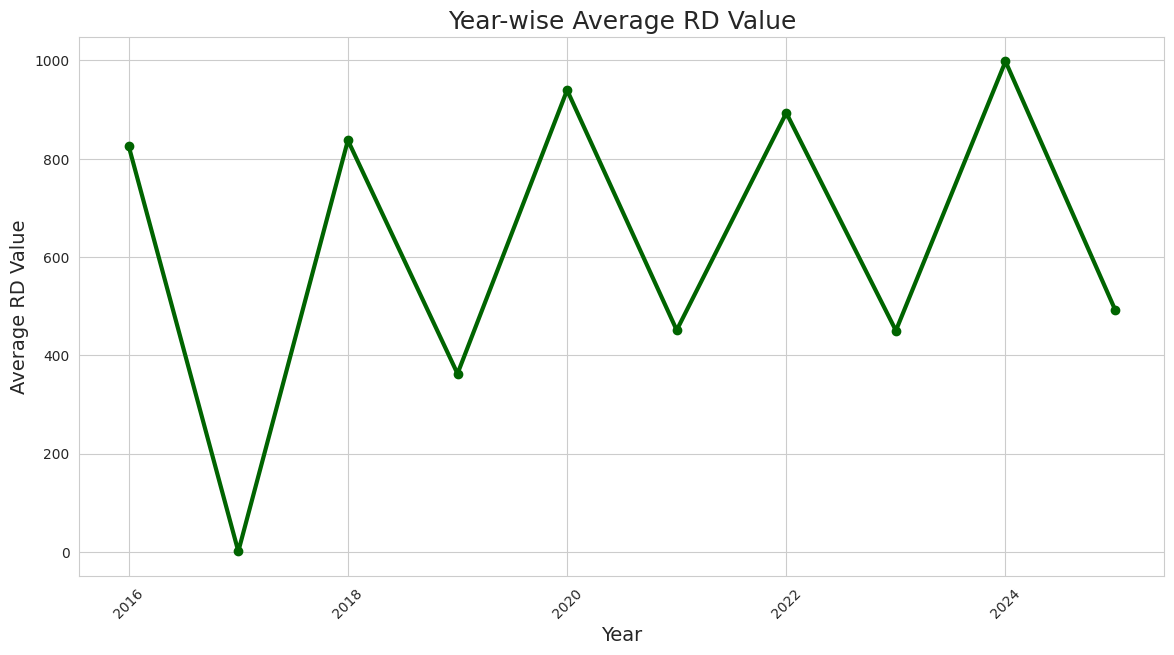

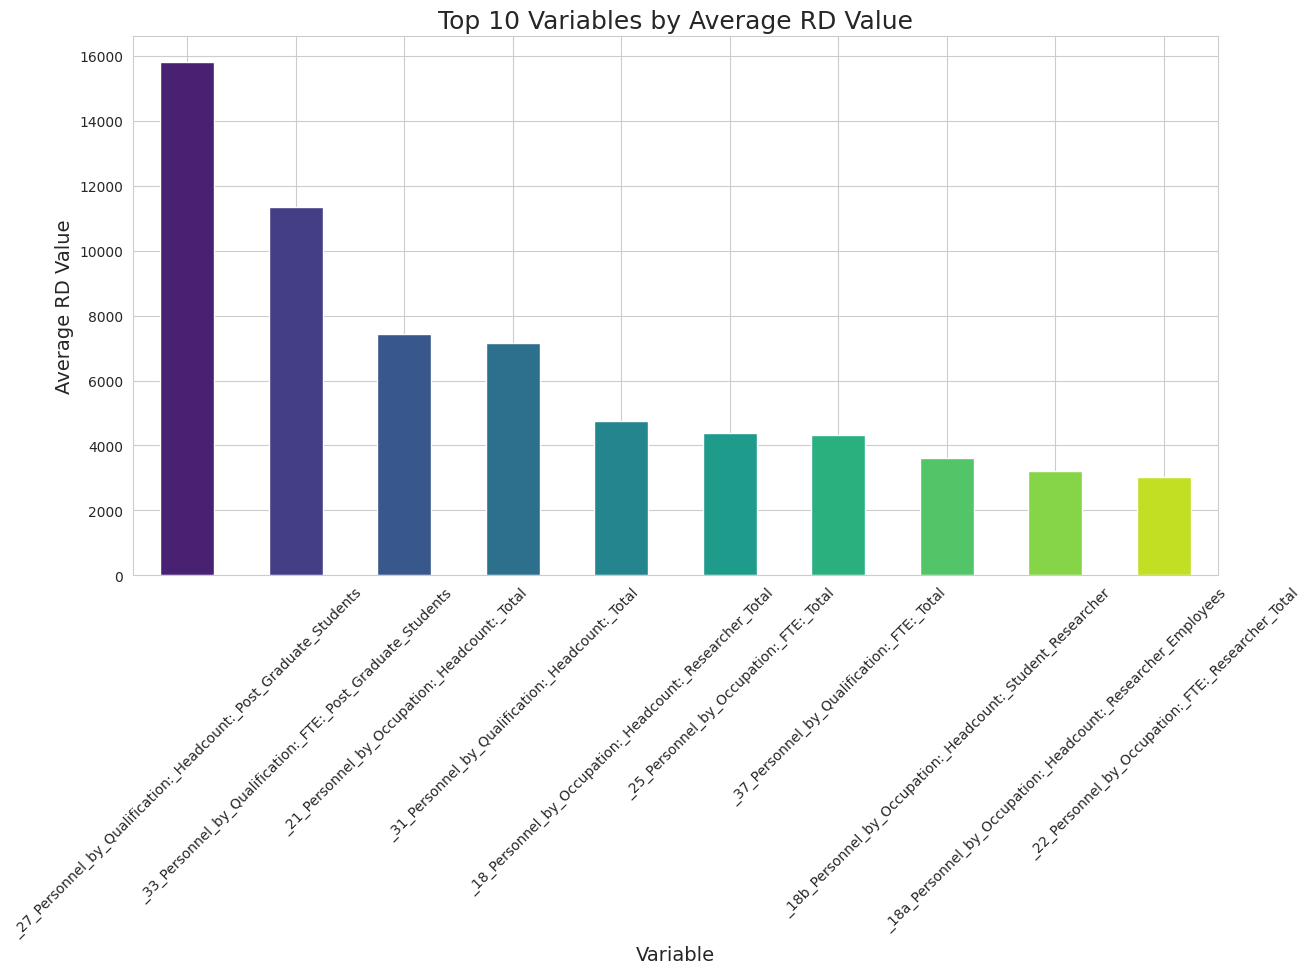

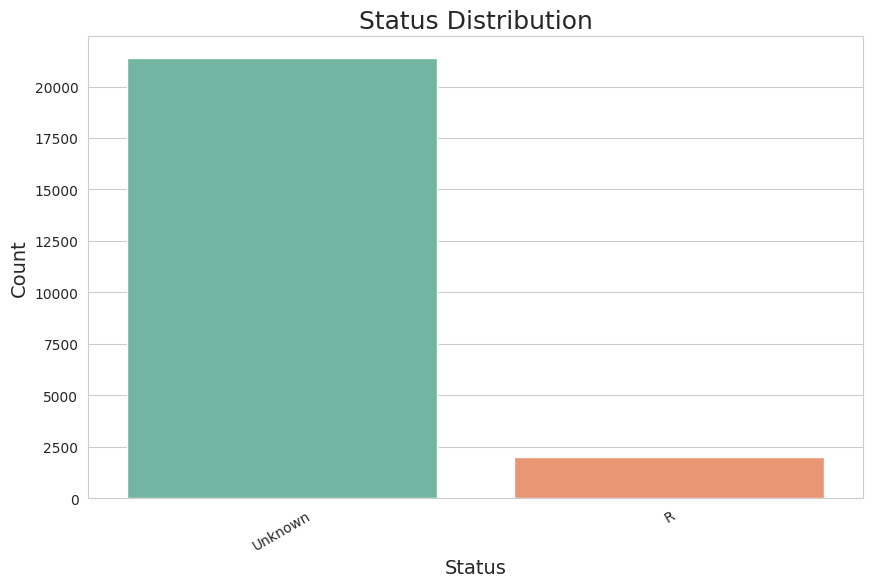

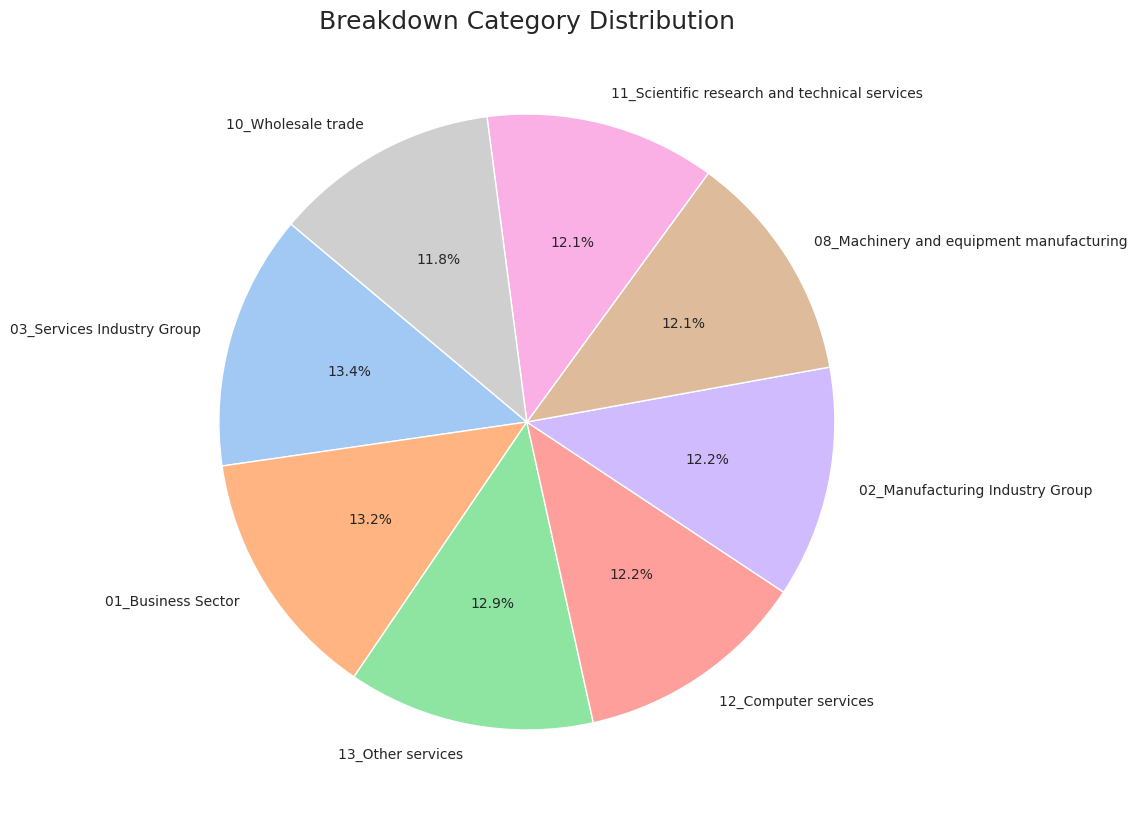

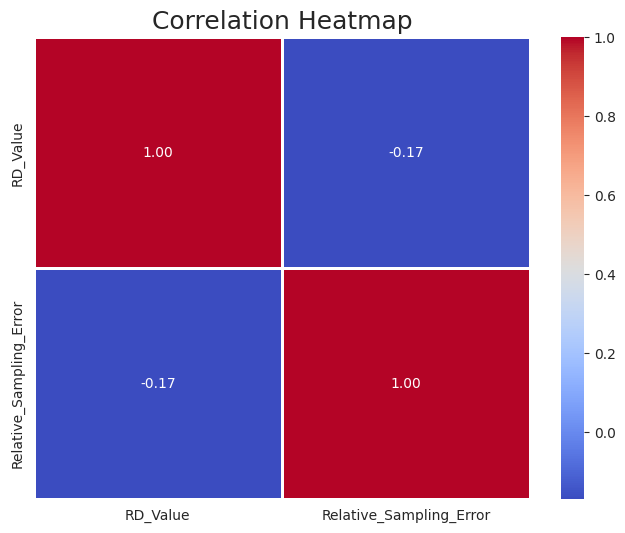

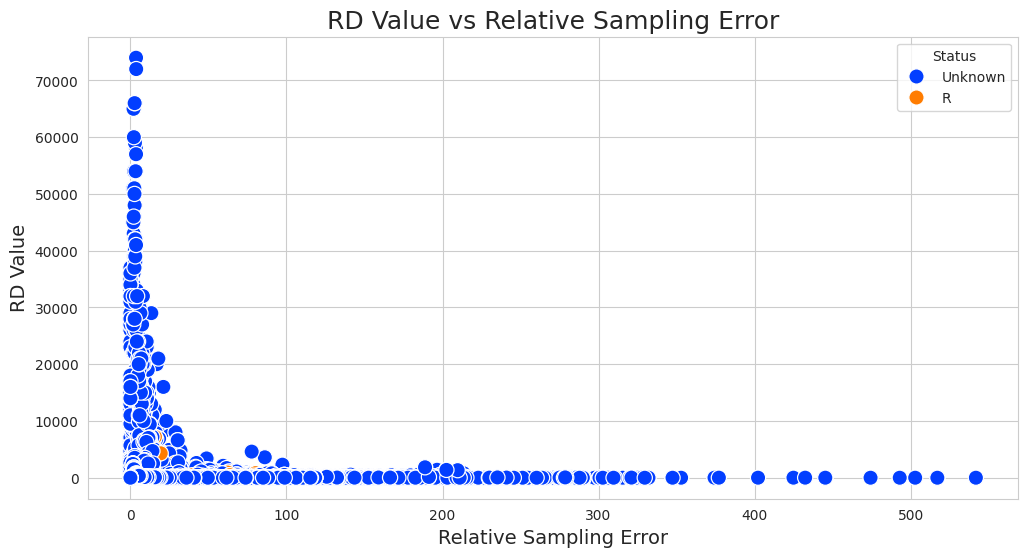

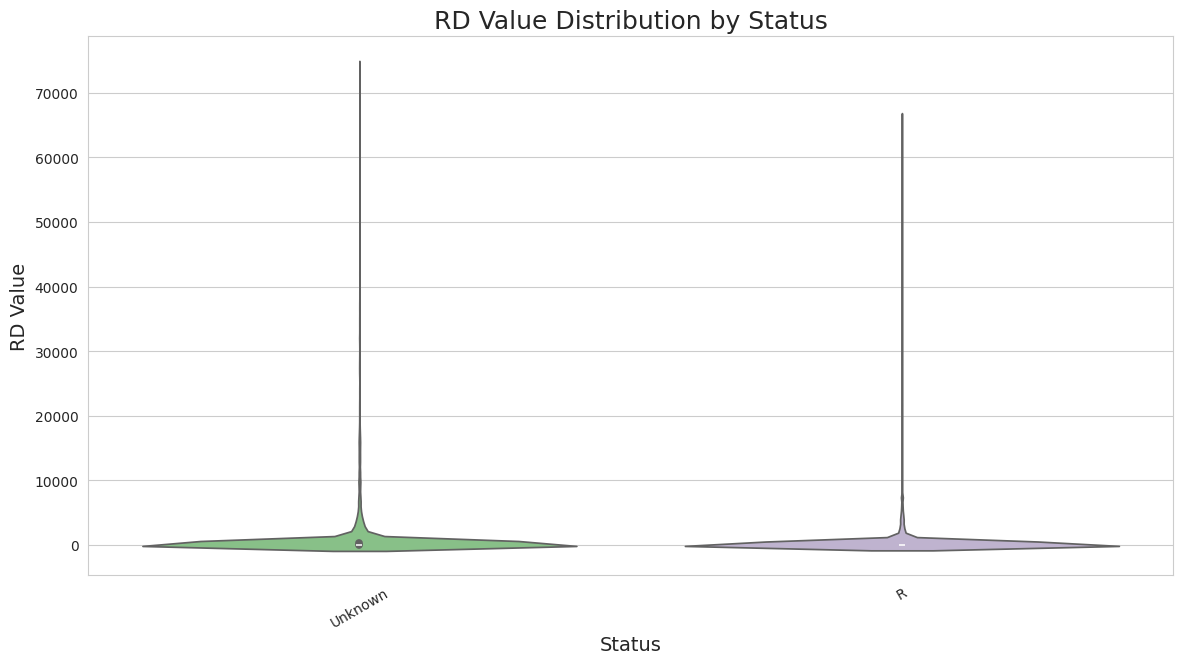

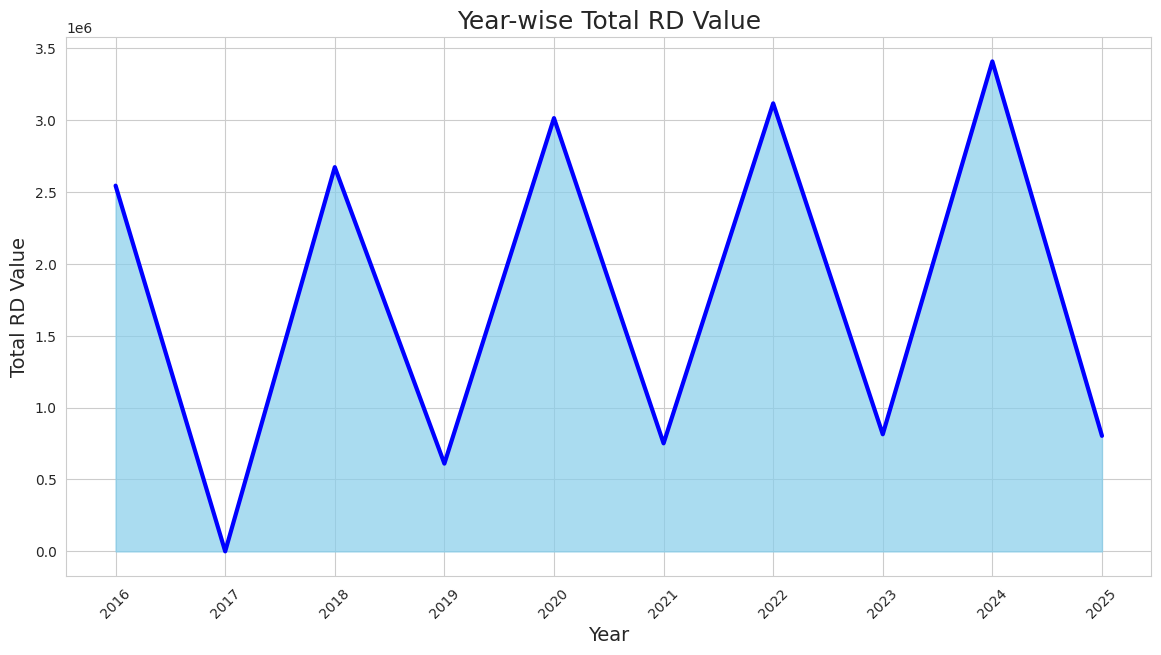

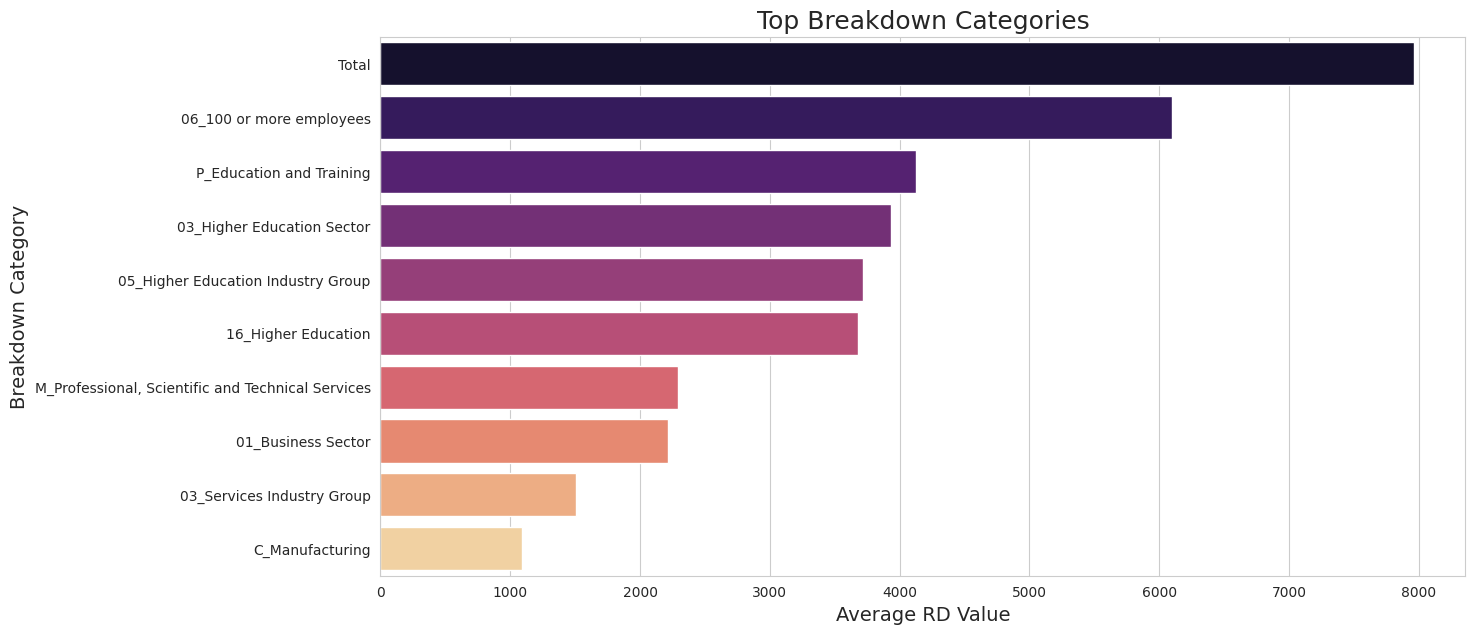

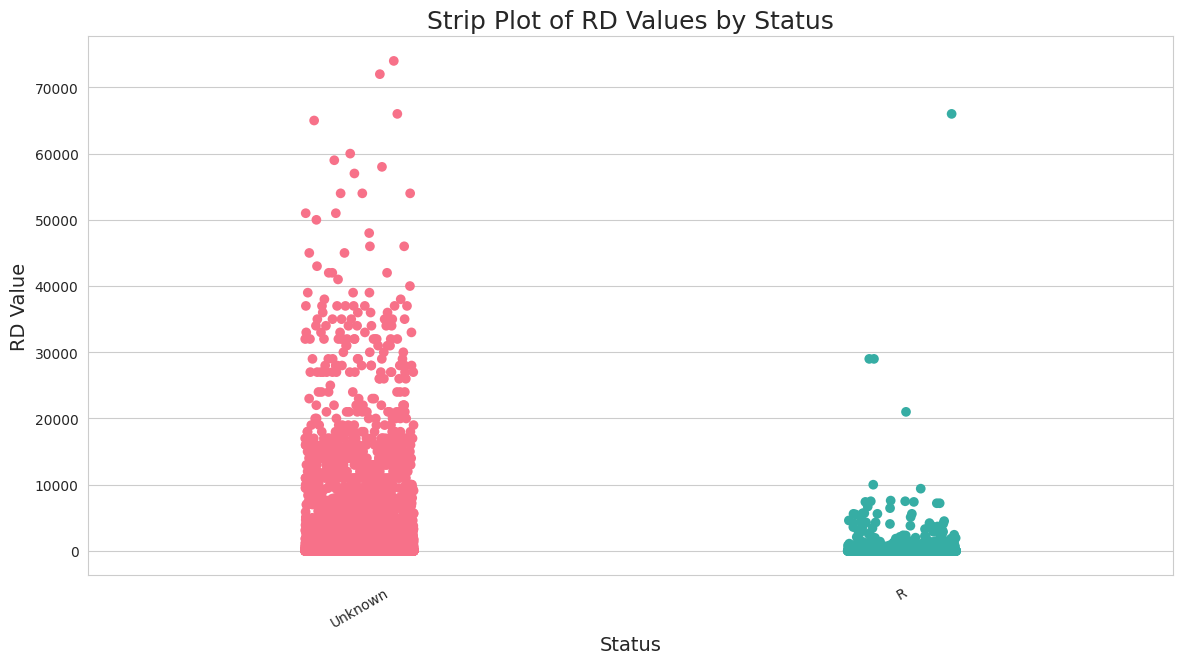

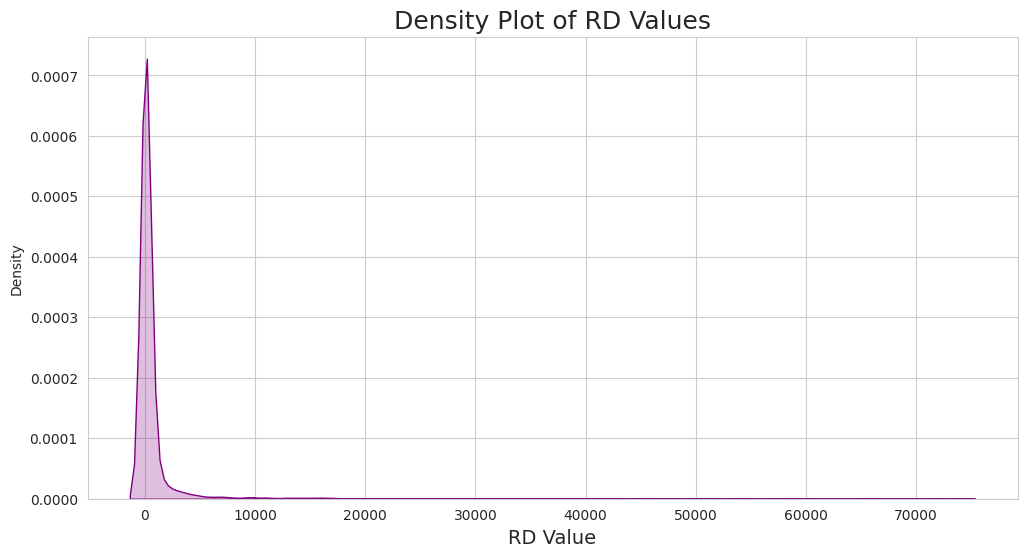

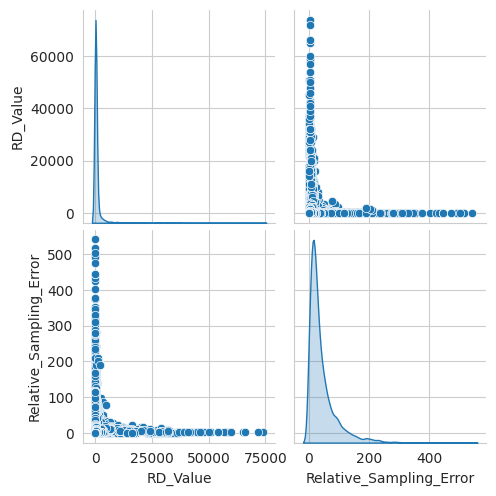

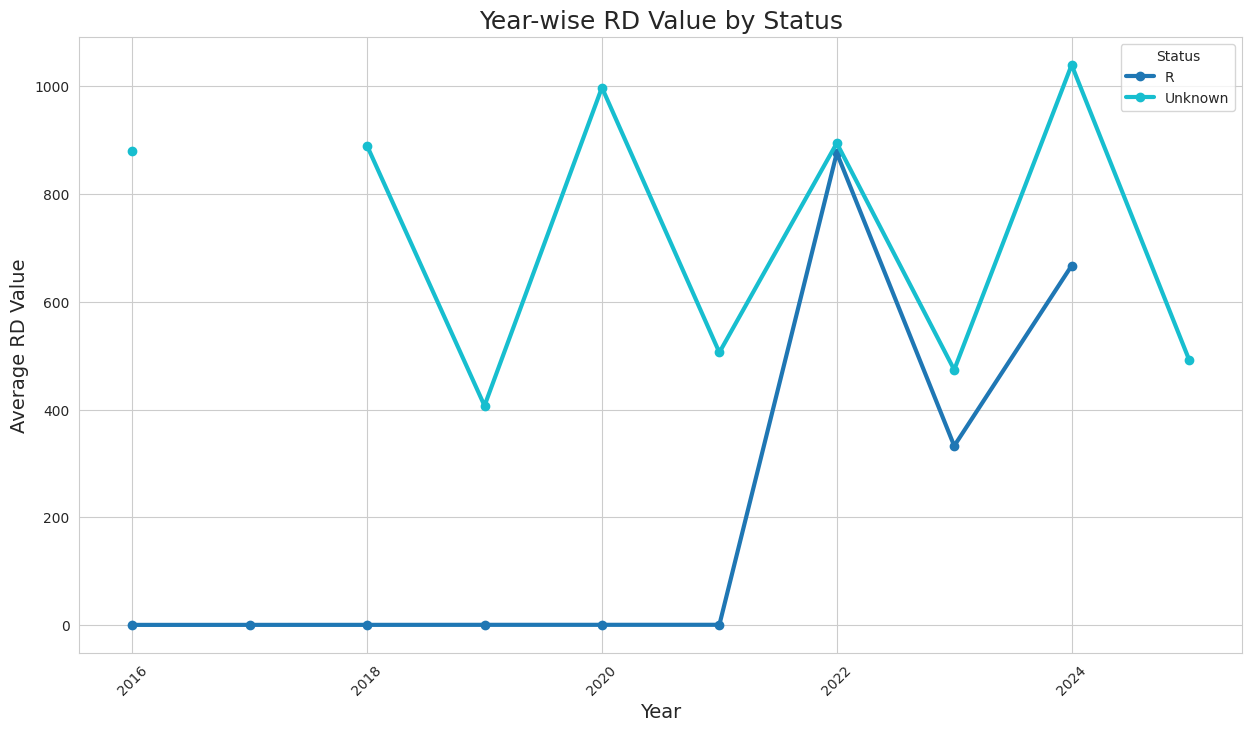

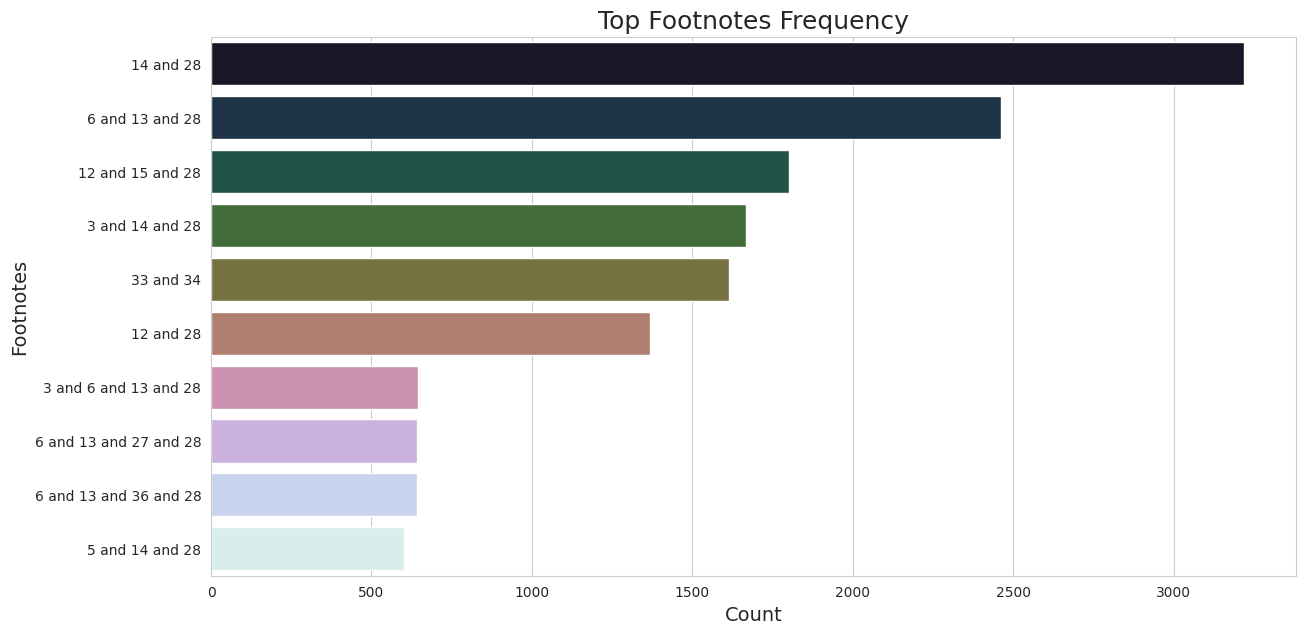

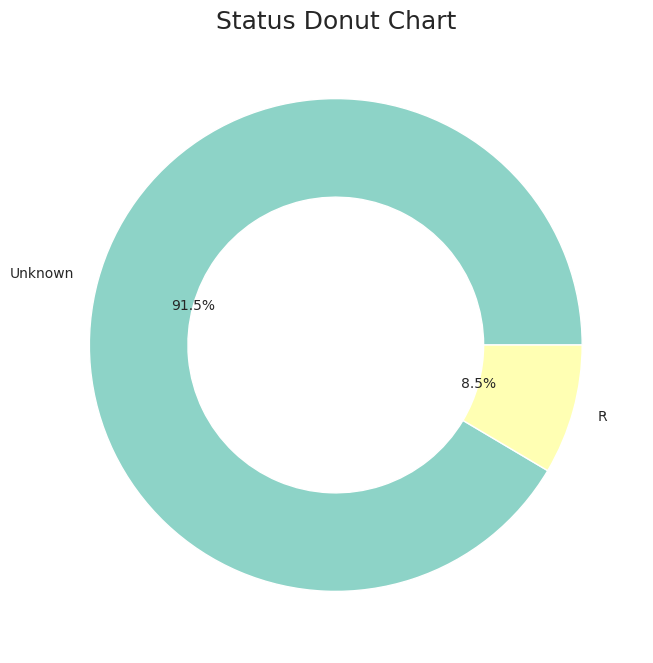

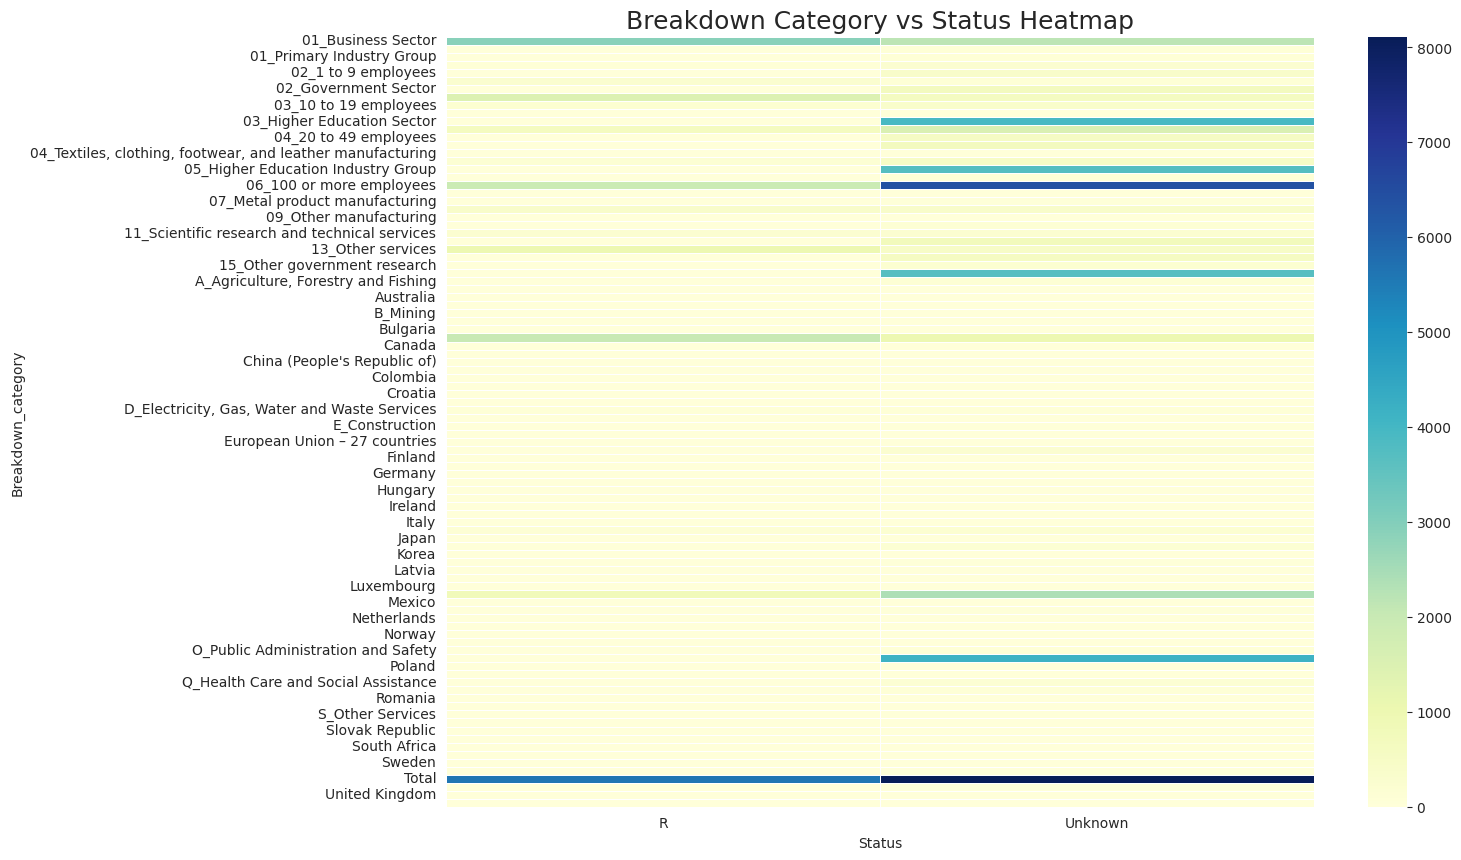


 ALL VISUALIZATIONS COMPLETED SUCCESSFULLY 


In [14]:
# Convert Year to string if needed
df['Year'] = df['Year'].astype(str)

# Convert RD_Value to numeric
df['RD_Value'] = pd.to_numeric(df['RD_Value'], errors='coerce')

# Remove missing RD_Value rows
df = df.dropna(subset=['RD_Value'])

# Fill missing categorical values
categorical_cols = [
    'Variable',
    'Breakdown',
    'Breakdown_category',
    'Status',
    'Unit'
]

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# ================= STYLE SETTINGS =================
sns.set_style("whitegrid")

# =========================================================
# 1. HISTOGRAM OF RD_VALUE
# =========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='RD_Value',
    bins=30,
    color='royalblue',
    kde=True
)

plt.title('Distribution of RD Values', fontsize=18)
plt.xlabel('RD Value', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.show()

# =========================================================
# 2. BOXPLOT OF RD_VALUE
# =========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['RD_Value'],
    color='tomato'
)

plt.title('Boxplot of RD Values', fontsize=18)
plt.xlabel('RD Value', fontsize=14)

plt.show()

# =========================================================
# 3. YEAR-WISE AVERAGE RD VALUE
# =========================================================

year_avg = df.groupby('Year')['RD_Value'].mean().sort_index()

plt.figure(figsize=(14,7))

year_avg.plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='darkgreen'
)

plt.title('Year-wise Average RD Value', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average RD Value', fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 4. BARPLOT OF TOP VARIABLES
# =========================================================

top_variables = (
    df.groupby('Variable')['RD_Value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

colors = sns.color_palette('viridis', len(top_variables))

top_variables.plot(
    kind='bar',
    color=colors
)

plt.title('Top 10 Variables by Average RD Value', fontsize=18)
plt.xlabel('Variable', fontsize=14)
plt.ylabel('Average RD Value', fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 5. COUNTPLOT OF STATUS
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Status',
    palette='Set2'
)

plt.title('Status Distribution', fontsize=18)
plt.xlabel('Status', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 6. PIE CHART OF BREAKDOWN CATEGORY
# =========================================================

breakdown_counts = df['Breakdown_category'].value_counts().head(8)

plt.figure(figsize=(10,10))

colors = sns.color_palette('pastel')

plt.pie(
    breakdown_counts,
    labels=breakdown_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

plt.title('Breakdown Category Distribution', fontsize=18)

plt.show()

# =========================================================
# 7. HEATMAP OF CORRELATION (FIXED)
# =========================================================

# Convert columns to numeric safely
df['RD_Value'] = pd.to_numeric(df['RD_Value'], errors='coerce')

df['Relative_Sampling_Error'] = pd.to_numeric(
    df['Relative_Sampling_Error'],
    errors='coerce'
)

# Select only numeric columns
numeric_cols = [
    'RD_Value',
    'Relative_Sampling_Error'
]

# Drop missing values
corr_df = df[numeric_cols].dropna()

# Correlation matrix
corr = corr_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=18)

plt.show()

# =========================================================
# 8. SCATTERPLOT
# =========================================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Relative_Sampling_Error',
    y='RD_Value',
    hue='Status',
    palette='bright',
    s=120
)

plt.title('RD Value vs Relative Sampling Error', fontsize=18)
plt.xlabel('Relative Sampling Error', fontsize=14)
plt.ylabel('RD Value', fontsize=14)

plt.show()

# =========================================================
# 9. VIOLIN PLOT
# =========================================================

plt.figure(figsize=(14,7))

sns.violinplot(
    data=df,
    x='Status',
    y='RD_Value',
    palette='Accent'
)

plt.title('RD Value Distribution by Status', fontsize=18)
plt.xlabel('Status', fontsize=14)
plt.ylabel('RD Value', fontsize=14)

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 10. AREA CHART YEARWISE
# =========================================================

year_sum = df.groupby('Year')['RD_Value'].sum().sort_index()

plt.figure(figsize=(14,7))

plt.fill_between(
    year_sum.index,
    year_sum.values,
    color='skyblue',
    alpha=0.7
)

plt.plot(
    year_sum.index,
    year_sum.values,
    color='blue',
    linewidth=3
)

plt.title('Year-wise Total RD Value', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total RD Value', fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 11. TOP BREAKDOWN CATEGORIES
# =========================================================

top_breakdowns = (
    df.groupby('Breakdown_category')['RD_Value']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_breakdowns.values,
    y=top_breakdowns.index,
    palette='magma'
)

plt.title('Top Breakdown Categories', fontsize=18)
plt.xlabel('Average RD Value', fontsize=14)
plt.ylabel('Breakdown Category', fontsize=14)

plt.show()

# =========================================================
# 12. STRIP PLOT
# =========================================================

plt.figure(figsize=(14,7))

sns.stripplot(
    data=df,
    x='Status',
    y='RD_Value',
    hue='Status',
    palette='husl',
    jitter=True,
    size=7
)

plt.title('Strip Plot of RD Values by Status', fontsize=18)
plt.xlabel('Status', fontsize=14)
plt.ylabel('RD Value', fontsize=14)

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 13. KDE PLOT
# =========================================================

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x='RD_Value',
    fill=True,
    color='purple'
)

plt.title('Density Plot of RD Values', fontsize=18)
plt.xlabel('RD Value', fontsize=14)

plt.show()

# =========================================================
# 14. PAIRPLOT
# =========================================================

pairplot_df = df[[
    'RD_Value',
    'Relative_Sampling_Error'
]].dropna()

sns.pairplot(
    pairplot_df,
    diag_kind='kde',
    palette='cool'
)

plt.show()

# =========================================================
# 15. YEARWISE STATUS ANALYSIS
# =========================================================

pivot_df = pd.pivot_table(
    df,
    values='RD_Value',
    index='Year',
    columns='Status',
    aggfunc='mean'
)

pivot_df.plot(
    figsize=(15,8),
    colormap='tab10',
    linewidth=3,
    marker='o'
)

plt.title('Year-wise RD Value by Status', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average RD Value', fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 16. FOOTNOTES COUNT
# =========================================================

footnote_counts = df['Footnotes'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=footnote_counts.values,
    y=footnote_counts.index,
    palette='cubehelix'
)

plt.title('Top Footnotes Frequency', fontsize=18)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Footnotes', fontsize=14)

plt.show()

# =========================================================
# 17. DONUT CHART
# =========================================================

status_counts = df['Status'].value_counts()

plt.figure(figsize=(8,8))

colors = sns.color_palette('Set3')

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'width':0.4}
)

plt.title('Status Donut Chart', fontsize=18)

plt.show()

# =========================================================
# 18. CLUSTERED HEATMAP
# =========================================================

heatmap_data = pd.pivot_table(
    df,
    values='RD_Value',
    index='Breakdown_category',
    columns='Status',
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False,
    linewidths=0.5
)

plt.title('Breakdown Category vs Status Heatmap', fontsize=18)

plt.show()

# =========================================================
# COMPLETED
# =========================================================

print("\n================================================")
print(" ALL VISUALIZATIONS COMPLETED SUCCESSFULLY ")
print("================================================")


================ FIRST 5 ROWS ================

                   Variable       Breakdown  \
0  _01_Total_RD_Expenditure  ANZSIC_1_Digit   
1  _01_Total_RD_Expenditure  ANZSIC_1_Digit   
3  _01_Total_RD_Expenditure  ANZSIC_1_Digit   
5  _01_Total_RD_Expenditure  ANZSIC_1_Digit   
7  _01_Total_RD_Expenditure  ANZSIC_1_Digit   

                    Breakdown_category  Year  RD_Value   Status  \
0  A_Agriculture, Forestry and Fishing  2016      91.0  Unknown   
1  A_Agriculture, Forestry and Fishing  2018      89.0  Unknown   
3  A_Agriculture, Forestry and Fishing  2020      99.0  Unknown   
5  A_Agriculture, Forestry and Fishing  2022      94.0  Unknown   
7  A_Agriculture, Forestry and Fishing  2024     196.0  Unknown   

                    Unit Footnotes  Relative_Sampling_Error  
0  NZ Dollars (millions)        12                     23.8  
1  NZ Dollars (millions)        12                     51.7  
3  NZ Dollars (millions)        12                     30.2  
5  NZ Dollars (mi

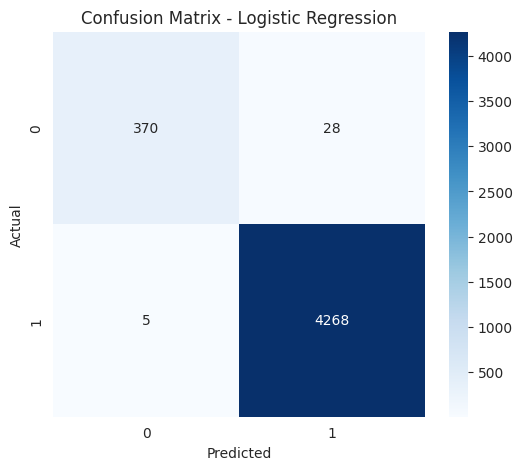

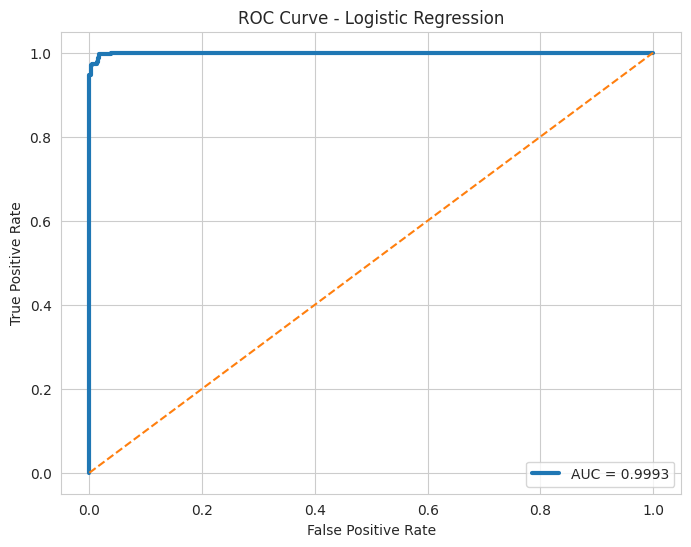

ROC-AUC Score : 0.9993


MODEL : Decision Tree

Accuracy Score : 0.9902

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       398
           1       0.99      1.00      0.99      4273

    accuracy                           0.99      4671
   macro avg       0.98      0.96      0.97      4671
weighted avg       0.99      0.99      0.99      4671



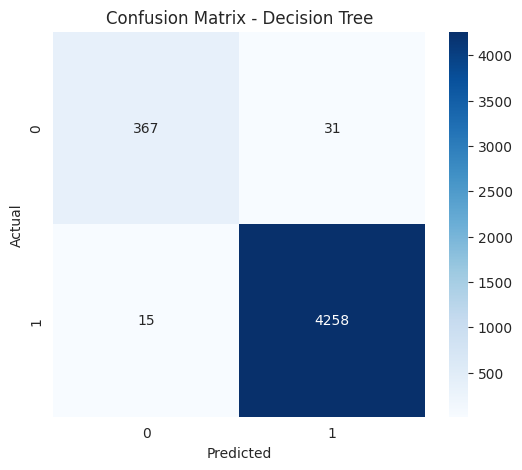

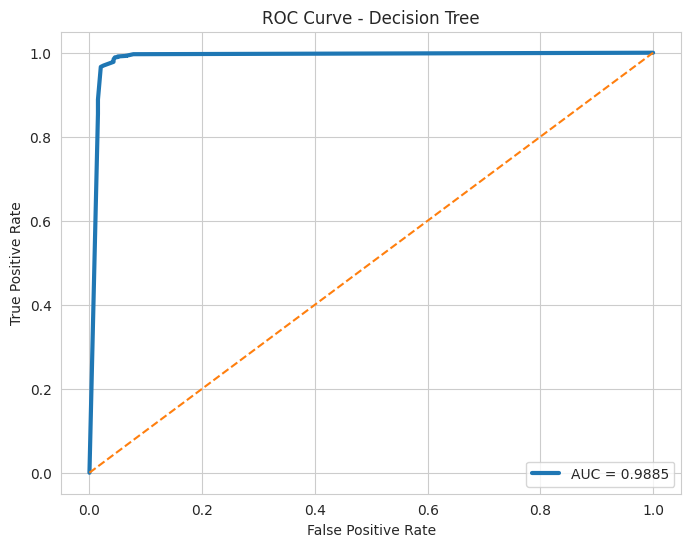

ROC-AUC Score : 0.9885


MODEL : Random Forest

Accuracy Score : 0.9906

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       398
           1       0.99      1.00      0.99      4273

    accuracy                           0.99      4671
   macro avg       0.99      0.95      0.97      4671
weighted avg       0.99      0.99      0.99      4671



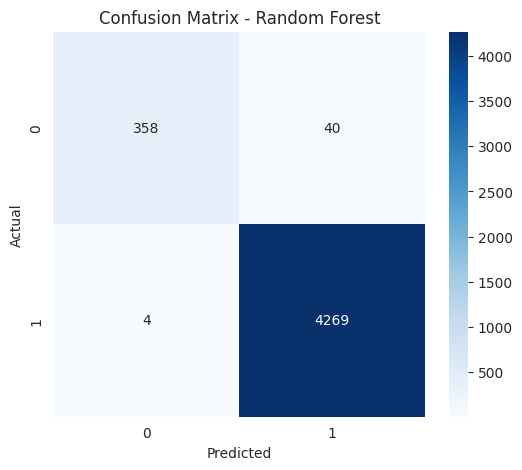

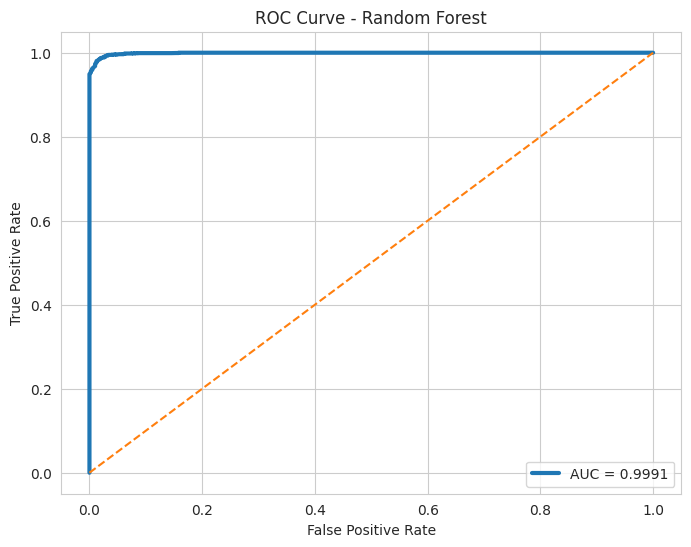

ROC-AUC Score : 0.9991


MODEL : Gradient Boosting

Accuracy Score : 0.9899

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       398
           1       0.99      1.00      0.99      4273

    accuracy                           0.99      4671
   macro avg       0.99      0.94      0.97      4671
weighted avg       0.99      0.99      0.99      4671



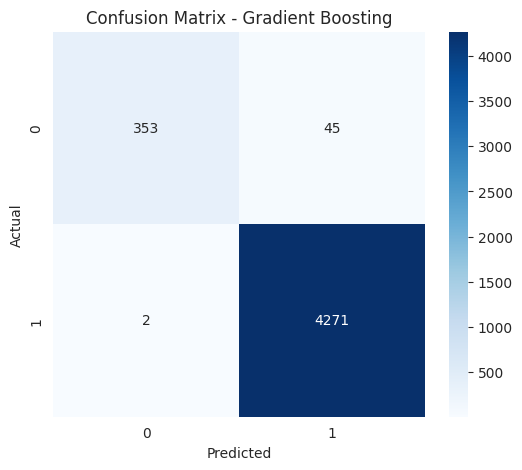

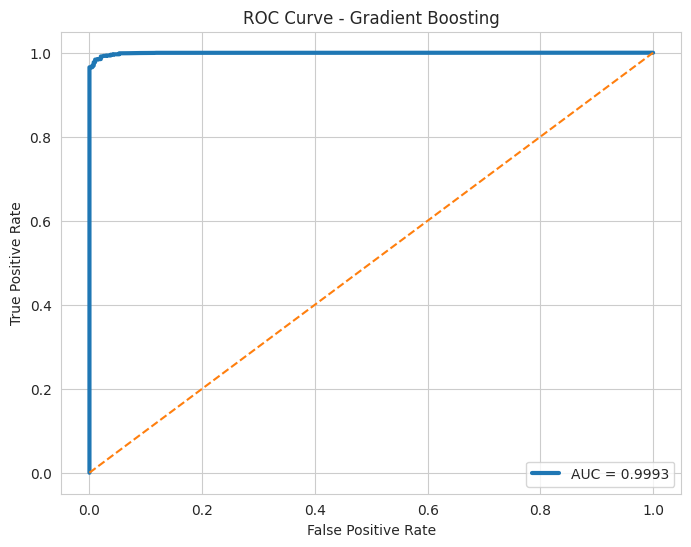

ROC-AUC Score : 0.9993


MODEL : Support Vector Machine

Accuracy Score : 0.9936

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       398
           1       0.99      1.00      1.00      4273

    accuracy                           0.99      4671
   macro avg       0.99      0.97      0.98      4671
weighted avg       0.99      0.99      0.99      4671



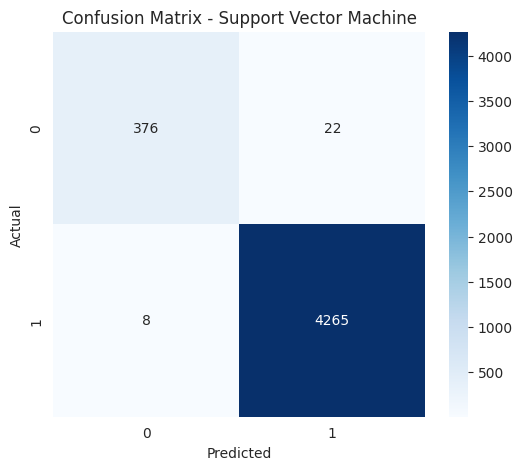

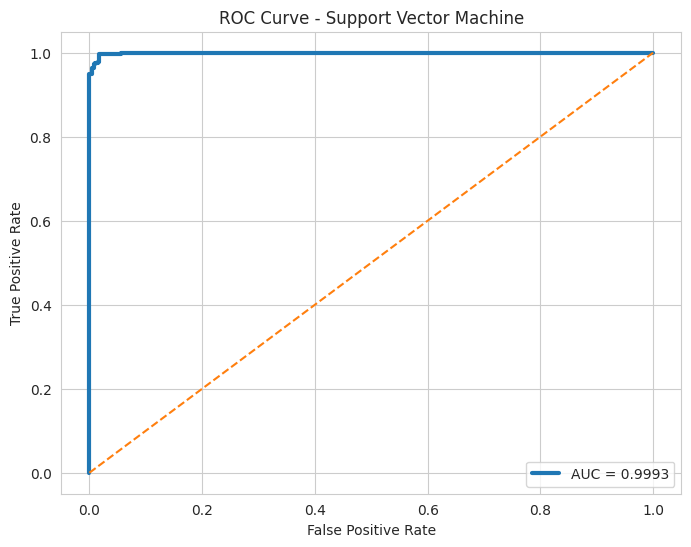

ROC-AUC Score : 0.9993


MODEL : K-Nearest Neighbors

Accuracy Score : 0.9889

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.90      0.93       398
           1       0.99      1.00      0.99      4273

    accuracy                           0.99      4671
   macro avg       0.98      0.95      0.96      4671
weighted avg       0.99      0.99      0.99      4671



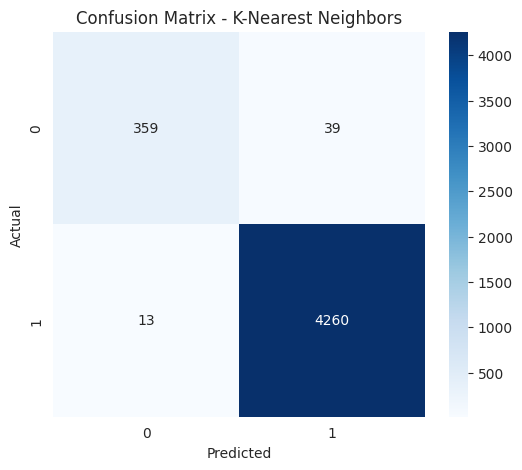

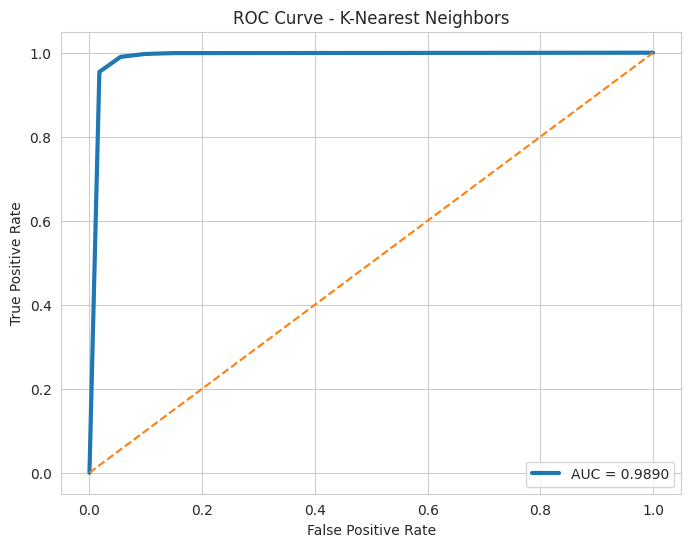

ROC-AUC Score : 0.9890

================ MODEL COMPARISON ================

                    Model  Accuracy
4  Support Vector Machine  0.993577
0     Logistic Regression  0.992935
2           Random Forest  0.990580
1           Decision Tree  0.990152
3       Gradient Boosting  0.989938
5     K-Nearest Neighbors  0.988867


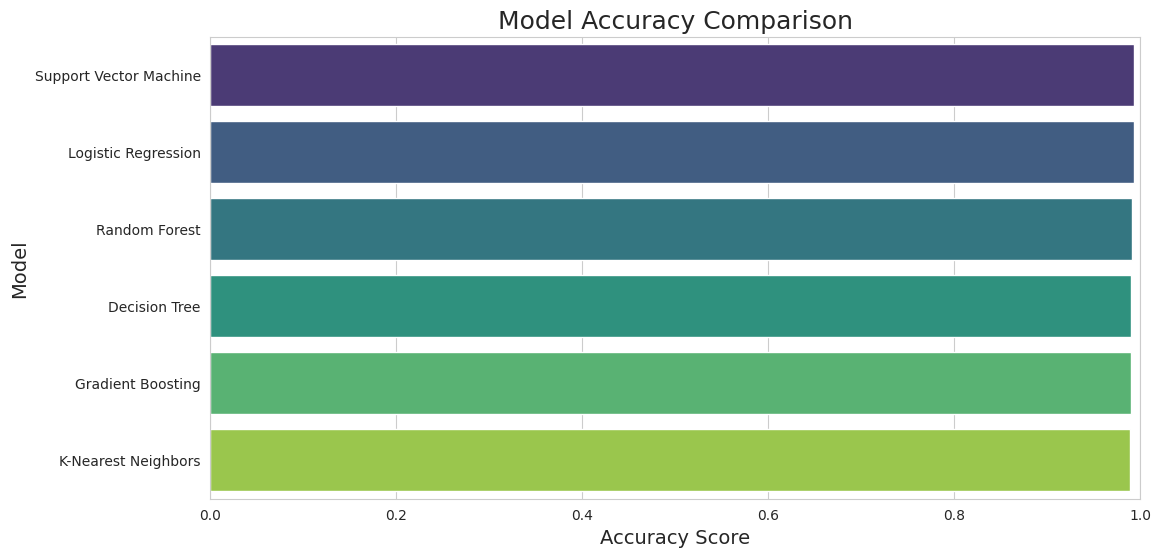


BEST MODEL
Model Name : Support Vector Machine
Accuracy   : 0.9936

================ TOP 20 FEATURES ================

                                               Feature  Importance
248                             Unit_Percentage of GDP    0.241469
132                                  Breakdown_Country    0.197312
0                                             RD_Value    0.081064
1                              Relative_Sampling_Error    0.056912
130  Variable__95_Total_RD_Expenditure_as_a_proport...    0.047134
127  Variable__92_Business_Sector_RD_Expenditure_as...    0.046364
128  Variable__93_Government_Sector_RD_Expenditure_...    0.039039
129  Variable__94_Higher_Education_Sector_RD_Expend...    0.036578
134                       Breakdown_Published_Industry    0.021425
244                         Unit_NZ Dollars (millions)    0.016158
242                                          Year_2024    0.014698
235                                          Year_2017    0.012804
246      

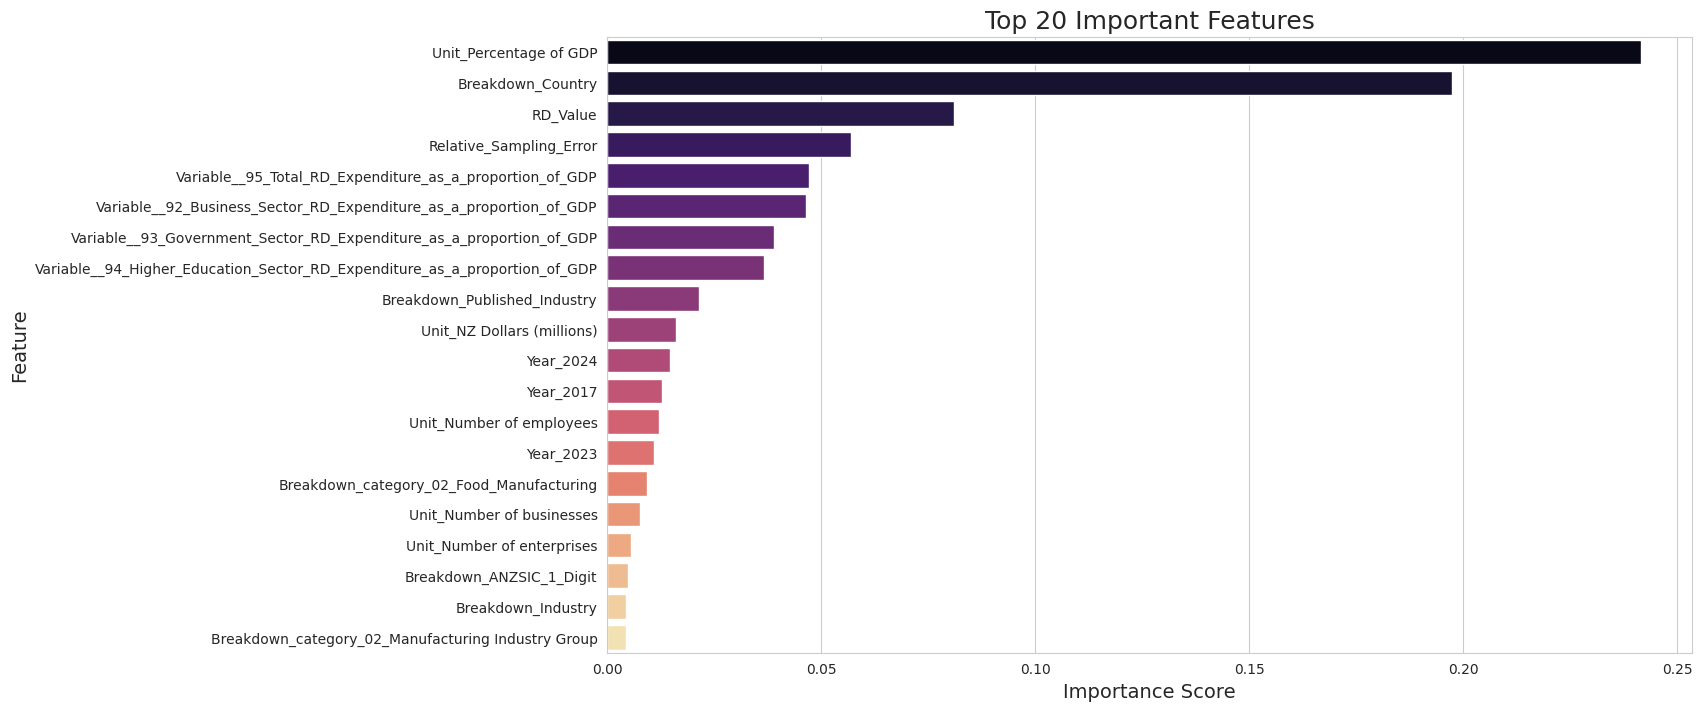


MACHINE LEARNING PIPELINE COMPLETED


In [15]:

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

# ML Models
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)



# =========================================================
# BASIC INFORMATION
# =========================================================

print("\n================ FIRST 5 ROWS ================\n")
print(df.head())

print("\n================ DATASET SHAPE ================\n")
print(df.shape)

print("\n================ DATA TYPES ================\n")
print(df.dtypes)

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

# =========================================================
# CLEAN NUMERIC COLUMNS
# =========================================================

df['RD_Value'] = pd.to_numeric(
    df['RD_Value'],
    errors='coerce'
)

df['Relative_Sampling_Error'] = pd.to_numeric(
    df['Relative_Sampling_Error'],
    errors='coerce'
)

# =========================================================
# DROP UNNECESSARY COLUMNS
# =========================================================

drop_cols = ['Footnotes']

df.drop(
    columns=drop_cols,
    inplace=True,
    errors='ignore'
)

# =========================================================
# TARGET COLUMN
# =========================================================

target_column = 'Status'

# Remove missing target rows
df = df.dropna(subset=[target_column])

# =========================================================
# LABEL ENCODE TARGET
# =========================================================

le = LabelEncoder()

df[target_column] = le.fit_transform(
    df[target_column]
)

print("\n================ TARGET CLASSES ================\n")

for i, cls in enumerate(le.classes_):
    print(f"{cls} --> {i}")

# =========================================================
# FEATURES & TARGET
# =========================================================

X = df.drop(columns=[target_column])

y = df[target_column]

# =========================================================
# IDENTIFY NUMERIC & CATEGORICAL COLUMNS
# =========================================================

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\n================ NUMERIC FEATURES ================\n")
print(numeric_features)

print("\n================ CATEGORICAL FEATURES ================\n")
print(categorical_features)

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

# Numeric Transformer
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Transformer
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))

])

# Final Preprocessor
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numeric_features),

        ('cat', categorical_transformer, categorical_features)

    ],

    sparse_threshold=0
)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\n================ TRAIN TEST SHAPES ================\n")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier()

}

# =========================================================
# STORE RESULTS
# =========================================================

accuracy_results = {}

# =========================================================
# TRAIN & EVALUATE MODELS
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL : {model_name}")
    print("="*70)

    # =====================================================
    # CREATE PIPELINE
    # =====================================================

    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    pipeline.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = pipeline.predict(X_test)

    # =====================================================
    # ACCURACY
    # =====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_results[model_name] = accuracy

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred
    ))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    # Only for binary classification
    if len(np.unique(y)) == 2:

        y_prob = pipeline.predict_proba(X_test)[:, 1]

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f'AUC = {roc_auc:.4f}'
        )

        plt.plot(
            [0,1],
            [0,1],
            linestyle='--'
        )

        plt.xlabel('False Positive Rate')

        plt.ylabel('True Positive Rate')

        plt.title(f'ROC Curve - {model_name}')

        plt.legend()

        plt.show()

        print(f"ROC-AUC Score : {roc_auc:.4f}")

# =========================================================
# MODEL COMPARISON
# =========================================================

results_df = pd.DataFrame({

    'Model': accuracy_results.keys(),

    'Accuracy': accuracy_results.values()

})

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n================ MODEL COMPARISON ================\n")

print(results_df)

# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    palette='viridis'
)

plt.title(
    'Model Accuracy Comparison',
    fontsize=18
)

plt.xlabel(
    'Accuracy Score',
    fontsize=14
)

plt.ylabel(
    'Model',
    fontsize=14
)

plt.xlim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = results_df.iloc[0]

print("\n================================================")
print("BEST MODEL")
print("================================================")

print(f"Model Name : {best_model['Model']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

# Train Random Forest
rf_pipeline.fit(X_train, y_train)

# =========================================================
# GET FEATURE NAMES
# =========================================================

ohe = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
]

encoded_cat_features = ohe.get_feature_names_out(
    categorical_features
)

all_features = np.concatenate([
    numeric_features,
    encoded_cat_features
])

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': importances

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print("\n================ TOP 20 FEATURES ================\n")

print(feature_importance_df)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(14,8))

sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature',
    palette='magma'
)

plt.title(
    'Top 20 Important Features',
    fontsize=18
)

plt.xlabel(
    'Importance Score',
    fontsize=14
)

plt.ylabel(
    'Feature',
    fontsize=14
)

plt.show()

# =========================================================
# COMPLETED
# =========================================================

print("\n================================================")
print("MACHINE LEARNING PIPELINE COMPLETED")
print("================================================")

## Thank you...pls upvote!!!!!!!!!!!